# Modify CLM surfdata with the LPJ-GUESS FPC change (semi-realistic)

**Goal.** Impose the future-minus-historical vegetation change simulated by LPJ-GUESS on the CLM surface dataset variable `PCT_NAT_PFT`(the % of each natural PFT on the natural-veg land unit).

#### The problem: two different vegetation currencies

LPJ-GUESS and CLM describe how much of each plant functional type (PFT) is
present, but in **different, non-equivalent variables**:

- **LPJ-GUESS → foliage projective cover (FPC).** The fraction of ground
  shaded by the vertical projection of a PFT's foliage. It is *light-defined*
  and follows a Lambert–Beer form: for trees
  `FPC = crown_footprint × (1 − exp(−0.5·LAI))`, for grasses
  `FPC = 1 − exp(−0.5·LAI)`. Two consequences matter here: FPC **saturates**
  with leaf area (dense canopies asymptote below 1), and it mixes *area*
  (crown footprint) with *density* (within-crown leaf area). Per-PFT FPCs are
  reported on the **natural land unit** and do not sum to 100%.

- **CLM → `PCT_NAT_PFT`.** The *areal* percentage of each natural PFT on the
  natural-vegetation land unit. It is a pure area partition summing to **100%**
  (including bare ground), with no leaf-density information — LAI is carried
  separately (and is prognostic in BGC compset).

So FPC is not an area and cannot be dropped into `PCT_NAT_PFT` naively: it is
a saturating, density-laden cover on a land-unit basis that sums to <1, versus
a bare-inclusive area partition that sums to 100.

#### Adequancy of FPC as distribution proxy
Using the paired FPC and LAI fields, we
   separate the part of the change that is genuine range expansion
   (colonisation of new cells) from in-place leaf-area change. The majority of
   the boreal-tree signal is range shift, which supports using FPC as a
   distribution proxy. See notebook: [....]

#### Methods used to build the modified surfdata

- **Anomaly, not absolute.** We apply the LPJ-GUESS *future − historical*
  difference (SSP5-8.5, 2071–2100 minus 1971–2000) to the original CLM
  configuration. This cancels the two models' shared/structural bias — the
  systematic FPC-vs-CLM offset visible in the baseline comparison — so only the
  *change* is transferred.

- **Conservation by construction.** The anomaly is built in a closed partition
  (bare + PFTs, summing to 1 on the land-unit basis) so it sums to zero per
  cell; adding it to CLM keeps `PCT_NAT_PFT` at 100% without renormalisation.
  Bare ground absorbs the net change, so PFTs outside the modified set are left
  untouched. Where the imposed expansion exceeds the available area, the
  increments are scaled proportionally to fit.

We only edit `PCT_NAT_PFT` (spatial distribution within the natural-veg land unit). We leave every other land-unit fraction and variables (`PCT_NATVEG`, `PCT_CROP`, ...) unchanged, and we leave LAI to CLM (it is prognostic in the BGC compset) — so LPJ provides *distribution*, CLM will simulate *leaf density*.

**What this notebook does.** A = LPJ-GUESS -> CLM conversion: load/regrid/aggregate · B = look at the data · C = FUTURE CLM PFT DISTRIBUTION: build the modified surfdata file · D = diagnostics.

**Environment.** Run in one conda-forge env holding xESMF *and* cartopy (`conda create -n lcc -c conda-forge esmpy xesmf cartopy xarray netcdf4 matplotlib jupyter`).

**Credits** this notebook originates from https://github.com/adelezaini/master-thesis/blob/master/notebooks/input/Modify-input-surfdata-map_REALISTIC.ipynb and was created with the help of ClaudeAI.

In [7]:
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, xesmf as xe
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as _dt
import warnings; warnings.filterwarnings("ignore")
 
plt.rcParams.update({"font.family": "STIXGeneral", "mathtext.fontset": "stix",
                     "axes.titlesize": 15, "font.size": 12})
xr.set_options(keep_attrs=True) # keep DataArray attributes through arithmetic (units, long_name, ...)

## Configuration
All paths and the PFT bookkeeping live here. `CONVERSION_SCHEME` is the one scientific knob: which LPJ PFTs sum into which CLM PFT.

In [6]:
# ---- paths --------------------------------------------------------
DATA     = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata")
SURF_IN  = DATA / "surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc"
FPC_HIST = DATA / "LPJ-GUESS/FPC/fpc1971to2000.txt"
FPC_FUT  = DATA / "LPJ-GUESS/FPC/GFDL-ESM4_SSP585_fpc2071to2100.txt"
SURF_OUT = DATA / "surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc"

 
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)   # lives next to the notebook
 
def savefig(fig, name, dpi=200):
    """Save a figure to figures/<name>.png and .pdf (vector for the paper)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    print("saved:", FIGDIR / f"{name}.png")
 
# ---- PFT bookkeeping -----------------------------------------------------
LPJ_NATURAL = ["BNE","BINE","BNS","TeNE","TeBE","IBS","TeBS","C3G",
               "HSE","HSS","LSE","LSS","GRT","EPDS","SPDS","CLM"]
 
# ---- LPJ -> CLM aggregation ---------------------------------------------
# CLM natpft index (target) = list of LPJ column names summed into it
#   - IBS -> BoBDT only: IBS as 100% boreal on this >45N gridlist.
#   - GRT + C3G -> aC3 (arctic C3 grass): graminoid tundra + cold C3 grass,
#     grouped by growth form; their maps complement spatially.
#   - all shrubs + dwarf shrubs -> BoBDS (CLM's single boreal shrub type).
#   - moss/lichen ('CLM') is NOT listed -> it falls into bare (see close step).
#     It is ~0% of cover in the domain, so this is harmless; set MOSS_TO_AC3
#     below if you prefer it counted as vegetated.
CONVERSION_SCHEME = {
    1:  ["TeNE"],                                  # TeNET
    2:  ["BNE", "BINE"],                           # BoNET
    3:  ["BNS"],                                   # BoNDT
    5:  ["TeBE"],                                  # TeBET
    7:  ["TeBS"],                                  # TeBDT
    8:  ["IBS"],                                   # BoBDT
    11: ["HSE","HSS","LSE","LSS","EPDS","SPDS"],   # BoBDS
    12: ["C3G","GRT"],                             # aC3
}
MOSS_TO_AC3 = False
if MOSS_TO_AC3:
    CONVERSION_SCHEME[12] = CONVERSION_SCHEME[12] + ["CLM"]
 
# PFTs we modify = the scheme keys. Bare (0) is the closure sink, handled apart.
PFTS_TO_CHANGE = list(CONVERSION_SCHEME.keys())
BARE = 0
# labels for plots only
CLM_NAMES = {0:"BG",1:"TeNET",2:"BoNET",3:"BoNDT",5:"TeBET",7:"TeBDT",
             8:"BoBDT",11:"BoBDS",12:"aC3",13:"C3"}

## LPJ-GUESS -> CLM PFT correspondence: how it was built

LPJ-GUESS and CLM use different PFT sets, so mapping one onto the other is not
a lookup. PFTs were matched along three axes, and where names were ambiguous,
by comparing spatial patterns.

### The three axes

1. **Growth form** — tree / shrub / grass / non-vascular. Primary axis: a PFT
   maps only to a CLM PFT of the same physiognomy.
2. **Leaf form** — needleleaved vs broadleaved.
3. **Phenology** — evergreen vs summergreen (deciduous). CLM encodes this in
   its names (Bo**N**eedleleaf **E**vergreen **T**ree vs Bo**N**eedleleaf
   **D**eciduous **T**ree), as does LPJ-GUESS (BNE evergreen vs BNS
   summergreen). 

### Clean 1:1 matches (trees)

Growth form + leaf form + phenology pin these down:
BNE/BINE->BoNET, BNS->BoNDT, TeNE->TeNET, TeBE->TeBET, TeBS->TeBDT,
IBS->BoBDT. Note: BNE vs BINE differ only in shade tolerance, which CLM does not resolve, so
both -> BoNET.

### Where names are not enough — spatial comparison

CLM's shrub/grass set is coarser than LPJ-GUESS's, so several LPJ PFTs share
one CLM PFT and the choice is not forced by naming. These were guided by
comparing the aggregated cover maps (the LPJ-vs-CLM figure, B4) and keeping
the grouping consistent with the observed pattern:

- **Shrubs (HSE, HSS, LSE, LSS) + prostrate dwarf shrubs (EPDS, SPDS) ->
  BoBDS**, CLM's single boreal shrub type. NOTE: CLM's only boreal shrub, BoBDS, is nominally *deciduous*, so the evergreen
shrubs (HSE, LSE) are mapped into it despite the phenology mismatch — no
evergreen boreal shrub PFT exists in CLM.
- **Graminoid & forb tundra (GRT) + cold C3 grass (C3G) -> arcticC3 (aC3).**
  GRT is a graminoid (grass growth form); its map and C3G's are spatially
  complementary, together reproducing the boreal/tundra grass cover, so both
  go to the arctic C3 grass PFT rather than to a shrub.
- **Cushion forb, lichen and moss (idx 15) -> bare:** non-vascular, negligible
  cover, no leaf-area/BVOC role — treated as unvegetated ground.

### Excluded

Peatland PFTs (16-22): CLM's natural-veg land unit has no peatland equivalent,
so peatland cover is dropped; the conversion operates on the
natural-vegetation fraction only.



## PFT conversion table (documentation)

saved: figures/pft_correspondence.csv
saved: figures/pft_correspondence.png


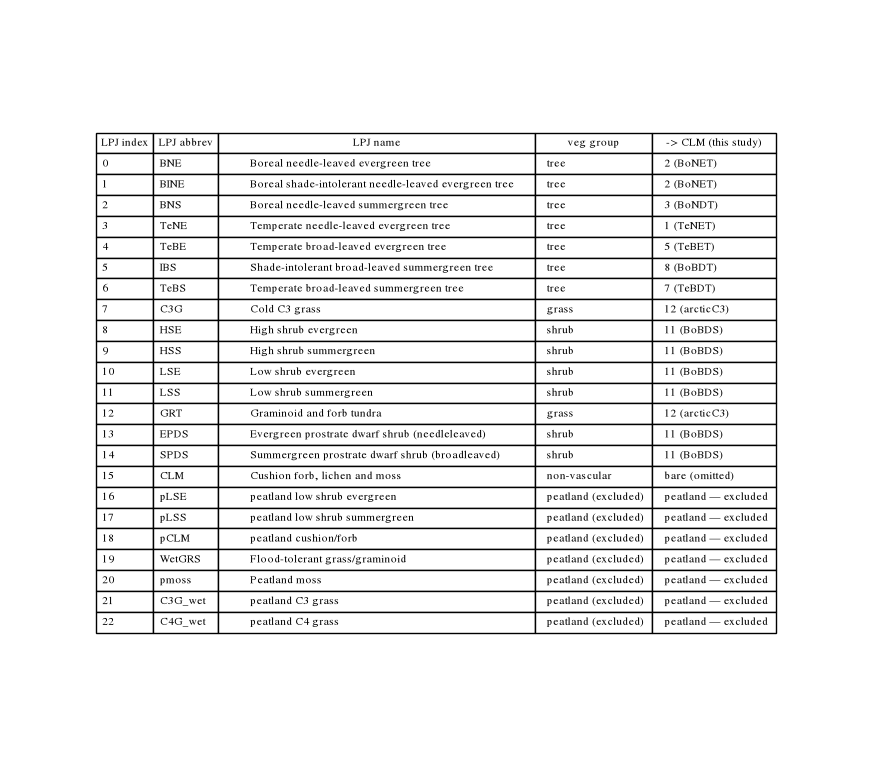

In [9]:
# LPJ-GUESS natural PFTs, descriptive names, growth group, and how each maps to
# a CLM natpft under the scheme used here (`CONVERSION_SCHEME`). 
# Saved to figures/ as CSV (+ PNG/PDF).

import pandas as pd

lpj_abbrev = LPJ_NATURAL + ["pLSE","pLSS","pCLM","WetGRS","pmoss","C3G_wet","C4G_wet"]
lpj_long = {
    0:"Boreal needle-leaved evergreen tree", 1:"Boreal shade-intolerant needle-leaved evergreen tree",
    2:"Boreal needle-leaved summergreen tree", 3:"Temperate needle-leaved evergreen tree",
    4:"Temperate broad-leaved evergreen tree", 5:"Shade-intolerant broad-leaved summergreen tree",
    6:"Temperate broad-leaved summergreen tree", 7:"Cold C3 grass",
    8:"High shrub evergreen", 9:"High shrub summergreen", 10:"Low shrub evergreen",
    11:"Low shrub summergreen", 12:"Graminoid and forb tundra",
    13:"Evergreen prostrate dwarf shrub (needleleaved)", 14:"Summergreen prostrate dwarf shrub (broadleaved)",
    15:"Cushion forb, lichen and moss",
    16:"peatland low shrub evergreen", 17:"peatland low shrub summergreen", 18:"peatland cushion/forb",
    19:"Flood-tolerant grass/graminoid", 20:"Peatland moss", 21:"peatland C3 grass", 22:"peatland C4 grass"}

# growth group — corrected & scheme-consistent:
#   0-6 tree · 7,12 grass · 8-11,13,14 shrub · 15 non-vascular · 16-22 peatland (excluded)
veg_group = {
    **{i: "tree" for i in range(7)},            # 0-6
    7: "grass",
    **{i: "shrub" for i in (8, 9, 10, 11)},     # tall/low shrubs
    12: "grass",                                # graminoid & forb tundra -> aC3
    13: "shrub", 14: "shrub",                   # prostrate dwarf shrubs
    15: "non-vascular",                         # cushion forb/lichen/moss
    **{i: "peatland (excluded)" for i in range(16, 23)},
}

clm_name = {0:"BG",1:"TeNET",2:"BoNET",3:"BoNDT",4:"TrBET",5:"TeBET",6:"TrBDT",
            7:"TeBDT",8:"BoBDT",9:"TeBES",10:"TeBDS",11:"BoBDS",12:"arcticC3",13:"C3",14:"C4"}
lpj_to_clm = {}
for clm_id, cols in CONVERSION_SCHEME.items():
    for c in cols:
        lpj_to_clm[c] = f"{clm_id} ({clm_name[clm_id]})"
if MOSS_TO_AC3:
    lpj_to_clm.setdefault("CLM", "12 (arcticC3)")   # moss -> bare
else:
    lpj_to_clm.setdefault("CLM", "bare (omitted)")   # moss -> bare

rows = []
for i, ab in enumerate(lpj_abbrev):
    rows.append({
        "LPJ index": i,
        "LPJ abbrev": ab,
        "LPJ name": lpj_long.get(i, "?"),
        "veg group": veg_group.get(i, "?"),
        "-> CLM (this study)": lpj_to_clm.get(ab, "peatland — excluded" if i >= 16 else "bare"),
    })
df = pd.DataFrame(rows).set_index("LPJ index")

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
df.to_csv(FIGDIR / "pft_correspondence.csv")
print("saved:", FIGDIR / "pft_correspondence.csv")

fig, ax = plt.subplots(figsize=(11, 0.4*len(df) + 0.5)); ax.axis("off")
tbl = ax.table(cellText=df.reset_index().values, colLabels=df.reset_index().columns,
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.25)
tbl.auto_set_column_width(range(len(df.columns) + 1))
fig.savefig(FIGDIR / "pft_correspondence.png", dpi=200, bbox_inches="tight")
fig.savefig(FIGDIR / "pft_correspondence.pdf", bbox_inches="tight")
print("saved:", FIGDIR / "pft_correspondence.png")

#display(df)

## Helpers (inline for now; swap for `boreal_forest_expansion` package later)

- coordinate converters: CLM stores data on integer `lsmlat/lsmlon` index dims with 2-D `LATIXY/LONGXY` -> we convert to real 1-D `lat/lon` + from 0...360 to a -180..180 longitude.
- `make_grid`: xESMF conservative regridding needs cell-corner **bounds** (`lat_b/lon_b`), which we build as midpoints of a regular 1-D axis.
- `load_lpjguess_fpc`: reads the whitespace `.txt`, keeps the 16 natural PFTs, reshapes the (lon,lat) point list into a 2-D grid (NaN outside the gridlist).
- `boreal_map` / `panel`: polar maps. `boreal_map` returns `(ax, mappable)` so `panel` can build one shared colorbar. Swap these for the package versions when you move this into `boreal_forest_expansion`. ??

In [11]:
def convert_lsmcoord(ds):
    """ Replaces CLM’s lsmlat/lsmlon index dimensions with the actual 
    latitude/longitude values from LATIXY/LONGXY, and renames them to lat/lon."""
    ds = ds.copy()
    ds["lsmlat"] = ds["LATIXY"].isel(lsmlon=0)     # latitude is constant along lon
    ds["lsmlon"] = ds["LONGXY"].isel(lsmlat=0)     # longitude constant along lat
    return ds.rename({"lsmlat": "lat", "lsmlon": "lon"})
 
def convert360_180(da):
    """ Converts longitude coordinates from the 0–360° convention to 
    −180–180° and sorts them into increasing order. """
    da = da.copy()
    if float(da["lon"].min()) >= 0:
        da = da.assign_coords(lon=((da["lon"] + 180) % 360) - 180).sortby("lon")
    return da
 
def convert180_360(da):
    """ Converts longitude coordinates from −180–180° back to 0–360° 
    and restores increasing longitude order. """
    da = da.copy()
    if float(da["lon"].min()) < 0:
        da = da.assign_coords(lon=da["lon"] % 360).sortby("lon")
    return da
 
def _bounds_1d(x):
    """ Computes grid-cell boundary coordinates from 1-D cell centres 
    using midpoint interpolation and extrapolation at the outer edges."""
    x = np.asarray(x, float); mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([[x[0]-(mid[0]-x[0])], mid, [x[-1]+(x[-1]-mid[-1])]])
 
def make_grid(lat, lon):
    """ Creates an xarray latitude–longitude grid containing both cell 
    centres and cell boundaries, suitable for conservative regridding."""
    return xr.Dataset({"lat": ("lat", np.asarray(lat)), "lon": ("lon", np.asarray(lon)),
                       "lat_b": ("lat_b", _bounds_1d(lat)),
                       "lon_b": ("lon_b", _bounds_1d(lon))})
 
def load_lpjguess_fpc(path, names=LPJ_NATURAL):
    """ Reads LPJ-GUESS FPC output, selects the requested natural PFTs, 
    and reshapes the tabular data into a (natpft, lat, lon) xarray grid."""
    df = pd.read_csv(path, sep=r"\s+").set_index(["Lat", "Lon"])[names]
    da = xr.DataArray(df.values, coords={"lonlat": df.index, "natpft": names},
                      dims=["lonlat", "natpft"]).unstack("lonlat")
    # cells not in the >45N gridlist become NaN here (that's fine)
    return da.rename({"Lat": "lat", "Lon": "lon"}).transpose("natpft", "lat", "lon")
 
class MidpointNorm(mcolors.Normalize):
    """ Defines a Matplotlib colour normalization that places a chosen 
    midpoint—typically zero—at the centre of a diverging colour scale."""
    def __init__(self, vmin=None, vmax=None, midpoint=0.0, clip=False):
        self.midpoint = midpoint; super().__init__(vmin, vmax, clip)
    def __call__(self, value, clip=None):
        return np.ma.masked_array(np.interp(value, [self.vmin, self.midpoint, self.vmax],[0, 0.5, 1]))
 
def _circle(ax):
    """ Clips a polar map axis to a circular boundary to produce the 
    standard round Arctic-map appearance."""
    t = np.linspace(0, 2*np.pi, 100)
    ax.set_boundary(mpath.Path(np.vstack([np.sin(t), np.cos(t)]).T*0.5 + [0.5, 0.5]),transform=ax.transAxes)

def boreal_map(
    da, title="", ax=None, extent_lat=45, cmap="YlGn",
    vmin=None, vmax=None, diverging=False,
    levels=None, cbar=True, label="", **kw):
    """ Plots a latitude–longitude field on a circular Arctic orthographic 
    map, with optional diverging or discrete colour normalization and a colourbar."""
    
    if ax is None:
        plt.figure(figsize=(6, 6))
        ax = plt.axes(projection=ccrs.Orthographic(0, 90))

    ax.set_extent([-180, 180, extent_lat, 90], ccrs.PlateCarree())
    _circle(ax)

    if diverging and cmap == "YlGn":
        cmap = "BrBG"

    # ---- normalization / discrete colours ----
    if levels is not None:
        cmap = plt.get_cmap(cmap, len(levels) - 1)
        norm = mcolors.BoundaryNorm(levels, cmap.N)

        # Don't pass vmin/vmax together with norm
        plot_vmin = None
        plot_vmax = None

    else:
        norm = MidpointNorm(vmin, vmax, 0.0) if diverging else None
        plot_vmin = vmin
        plot_vmax = vmax

    p = da.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
                add_colorbar=False, cmap=cmap, vmin=plot_vmin, vmax=plot_vmax,
                norm=norm, **kw)

    ax.coastlines(linewidth=0.5)
    ax.gridlines(alpha=0.3)
    ax.set_title(title)

    if cbar:
        cb = plt.colorbar(p, ax=ax, location="bottom", pad=0.06,
                          shrink=0.75, aspect=35,extend="both",
                          boundaries=levels if levels is not None else None)
        cb.set_label(label)

    return ax, p

def panel(
    fields, titles, ncols=4, extent_lat=50, cmap="YlGn",
    vmin=None, vmax=None, diverging=False,
    levels=None,
    label="", **kw
):
    """ Creates a multi-panel collection of boreal maps using 
    a common colour scale and a single shared horizontal colourbar."""
    
    n = len(fields)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.4*ncols, 3.8*nrows + 0.6),
        subplot_kw={"projection": ccrs.Orthographic(0, 90)}
    )

    axes = np.atleast_1d(axes).ravel()
    p = None

    for ax, da, t in zip(axes, fields, titles):
        _, p = boreal_map(
            da, t,
            ax=ax,
            extent_lat=extent_lat,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            diverging=diverging,
            levels=levels,
            cbar=False,
            **kw
        )

    for ax in axes[n:]:
        ax.axis("off")

    fig.subplots_adjust(bottom=0.10, wspace=0.05, hspace=0.15)

    cax = fig.add_axes([0.25, 0.06, 0.5, 0.02])

    cb = fig.colorbar(
        p,
        cax=cax,
        orientation="horizontal",
        extend="both",
        boundaries=levels if levels is not None else None,
    )

    cb.set_label(label)

    return fig

## Part A — Load, regrid, aggregate (the ingredients)
### A1 · Load the CLM surfdata and define the land domain
The **mask matters a lot** (it caused a long debugging detour): a cell only belongs to our working domain if it is land, has natural veg, *and* its original `PCT_NAT_PFT` genuinely sums to 100. `.fillna(False)` makes the mask a clean boolean — without it, ocean NaNs propagate through `xr.where` later. Note: in this file `PCT_NAT_PFT` is not NaN over ocean — the `.fillna(False)` is defensive hygiene, not a fix for real NaNs.

In [12]:
surf     = xr.open_dataset(SURF_IN)
pct_clm  = convert360_180(convert_lsmcoord(surf)["PCT_NAT_PFT"])   # (natpft 0..14, lat, lon)
landfrac = convert360_180(convert_lsmcoord(surf)["LANDFRAC_PFT"])  # land/ocean fraction
natveg   = convert360_180(convert_lsmcoord(surf)["PCT_NATVEG"])    # natural-veg land-unit %
 
# valid = land AND natural veg present AND the column is a real 100% partition.
# .fillna(False): the mask is built from fields that are undefined over ocean,
# so we force any non-True result to False. This guarantees `valid` is a clean
# boolean; a float/NaN mask would make xr.where(valid, ...) propagate NaN
# instead of selecting a branch. (In this surfdata PCT_NAT_PFT itself is not
# NaN over ocean, but the .fillna(False) is the safe habit regardless.)
valid = ((landfrac > 0) & (natveg > 0) &
         (np.abs(pct_clm.sum("natpft") - 100) < 1e-3)).fillna(False)
print(f"valid land cells: {int(valid.sum())}  /  full grid {pct_clm.isel(natpft=0).size}")

valid land cells: 4914  /  full grid 13824


valid cells: 4914
non-domain cells (~valid): 8910
cells where PCT_NAT_PFT is truly NaN: 0


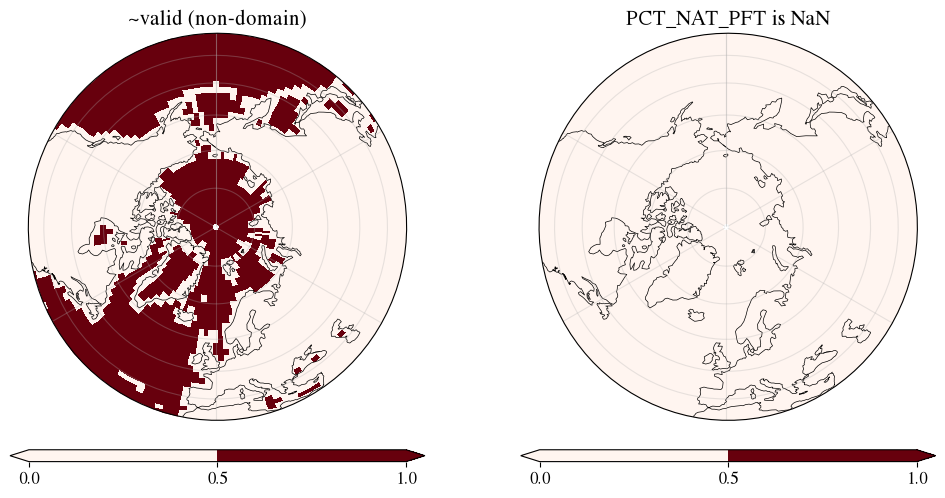

In [13]:
# %% where are the non-domain cells? (the "8910")
non_domain = (~valid)                      # everything outside the working land domain
raw_nan    = pct_clm.isnull().any("natpft")   # cells where PCT_NAT_PFT is actually NaN

print("valid cells:", int(valid.sum()))
print("non-domain cells (~valid):", int(non_domain.sum()))
print("cells where PCT_NAT_PFT is truly NaN:", int(raw_nan.sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5),
                         subplot_kw={"projection": ccrs.Orthographic(0, 90)})
# zoom out (extent_lat=-90) so you see the whole globe, not just the Arctic
boreal_map(non_domain.astype(float), "~valid (non-domain)", axes[0],
           cmap="Reds", vmin=0, vmax=1, extent_lat=30, cbar=True, levels=np.arange(0, 1.01, 0.5))   
boreal_map(raw_nan.astype(float), "PCT_NAT_PFT is NaN", axes[1],
           cmap="Reds", vmin=0, vmax=1, extent_lat=30, cbar=True, levels=np.arange(0, 1.01, 0.5))
plt.tight_layout()

### A2 · Load the LPJ-GUESS FPC, both time slices
16 natural PFTs, historical and future. FPC is already expressed per natural land unit (verified separately), i.e. the same basis as `PCT_NAT_PFT`.

In [32]:
fpc_hist = load_lpjguess_fpc(FPC_HIST)
fpc_fut  = load_lpjguess_fpc(FPC_FUT)
# fail loudly if the two slices aren't on the identical grid (the anomaly needs it)
xr.align(fpc_hist, fpc_fut, join="exact")

(<xarray.DataArray (natpft: 16, lat: 75, lon: 638)> Size: 6MB
 array([[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],
 
        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],
 
        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
 ...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],
 
        [[nan, nan, nan, ..., nan, nan, 

### A3 · Regrid LPJ 0.5deg -> CLM 1.9x2.5, with ONE shared regridder
`conservative_normed` is right for an intensive, land-only fraction: it normalises by the *valid* source area so coastal cells aren't diluted by empty ocean. Using the **same** regridder object for hist and future is what makes the regridding error cancel in `future - historical`.

In [33]:
regridder = xe.Regridder(make_grid(fpc_hist.lat.values, fpc_hist.lon.values),
                         make_grid(pct_clm.lat.values,  pct_clm.lon.values),
                         method="conservative_normed", periodic=True)  # periodic in lon
fpc_hist_clm = regridder(fpc_hist, keep_attrs=True)
fpc_fut_clm  = regridder(fpc_fut,  keep_attrs=True)

### A4 · Aggregate LPJ PFTs -> CLM PFTs
Pure linear sum per the conversion scheme. Because aggregation and regridding are both linear they commute; order doesn't matter.

In [34]:
def aggregate_to_clm(fpc_named, scheme=CONVERSION_SCHEME):
    slots = [fpc_named.sel(natpft=cols).sum("natpft")
                      .assign_coords(natpft=j).expand_dims("natpft")
             for j, cols in scheme.items()]
    return xr.concat(slots, dim="natpft").sortby("natpft")
 
V_hist = aggregate_to_clm(fpc_hist_clm)     # CLM-PFT FPC (fraction), historical
V_fut  = aggregate_to_clm(fpc_fut_clm)      # CLM-PFT FPC (fraction), future

## Part B — Visual exploration
Four looks at the data before any modification, to sanity-check inputs.
### B1 · CLM PFT distribution (what we start from: the PFTs we will modify)

Text(0.5, 1.02, 'CLM PCT_NAT_PFT  [% of natural veg land unit]')

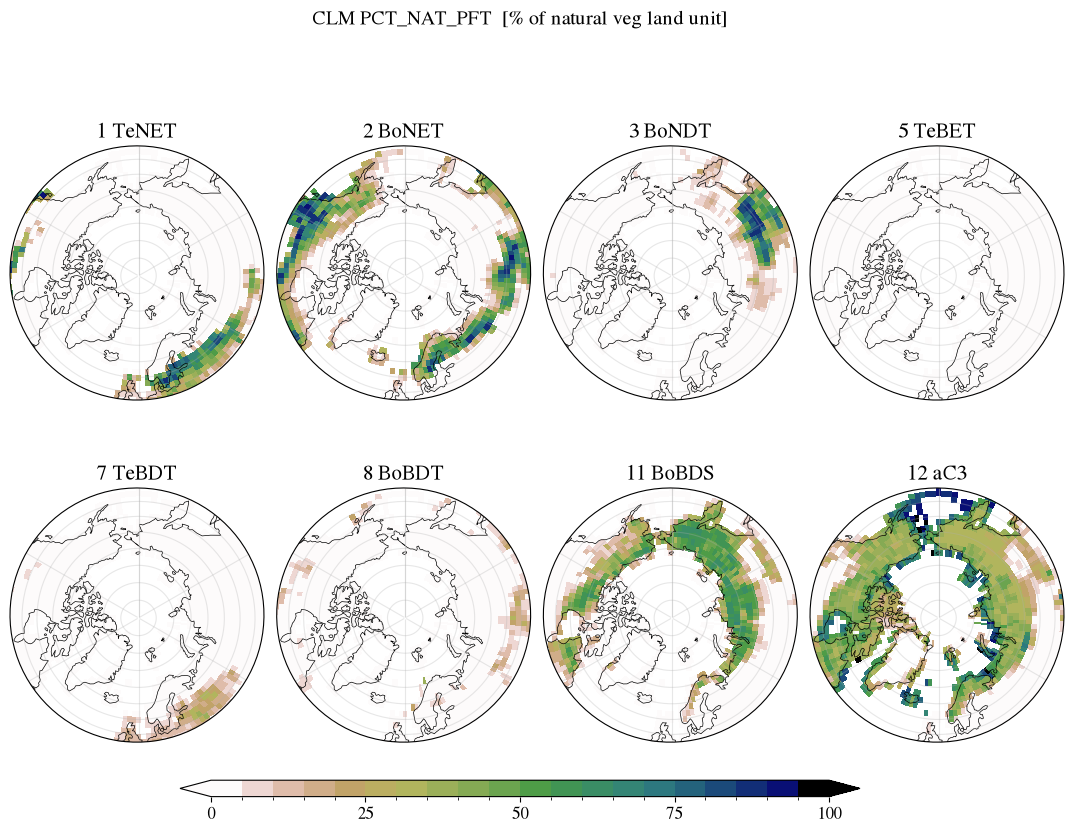

In [140]:
fig = panel([pct_clm.sel(natpft=p).where(valid) for p in PFTS_TO_CHANGE],
            [f"{p} {CLM_NAMES.get(p,'')}" for p in PFTS_TO_CHANGE],
            vmin=0, vmax=100, cmap="gist_earth_r", levels=np.arange(0, 101, 5))
fig.suptitle("CLM PCT_NAT_PFT  [% of natural veg land unit]", y=1.02)

### B2 · LPJ-GUESS PFT distribution (native 0.5deg, historical FPC)

Text(0.5, 1.01, 'LPJ-GUESS FPC 1971-2000  [fraction of natural land unit]')

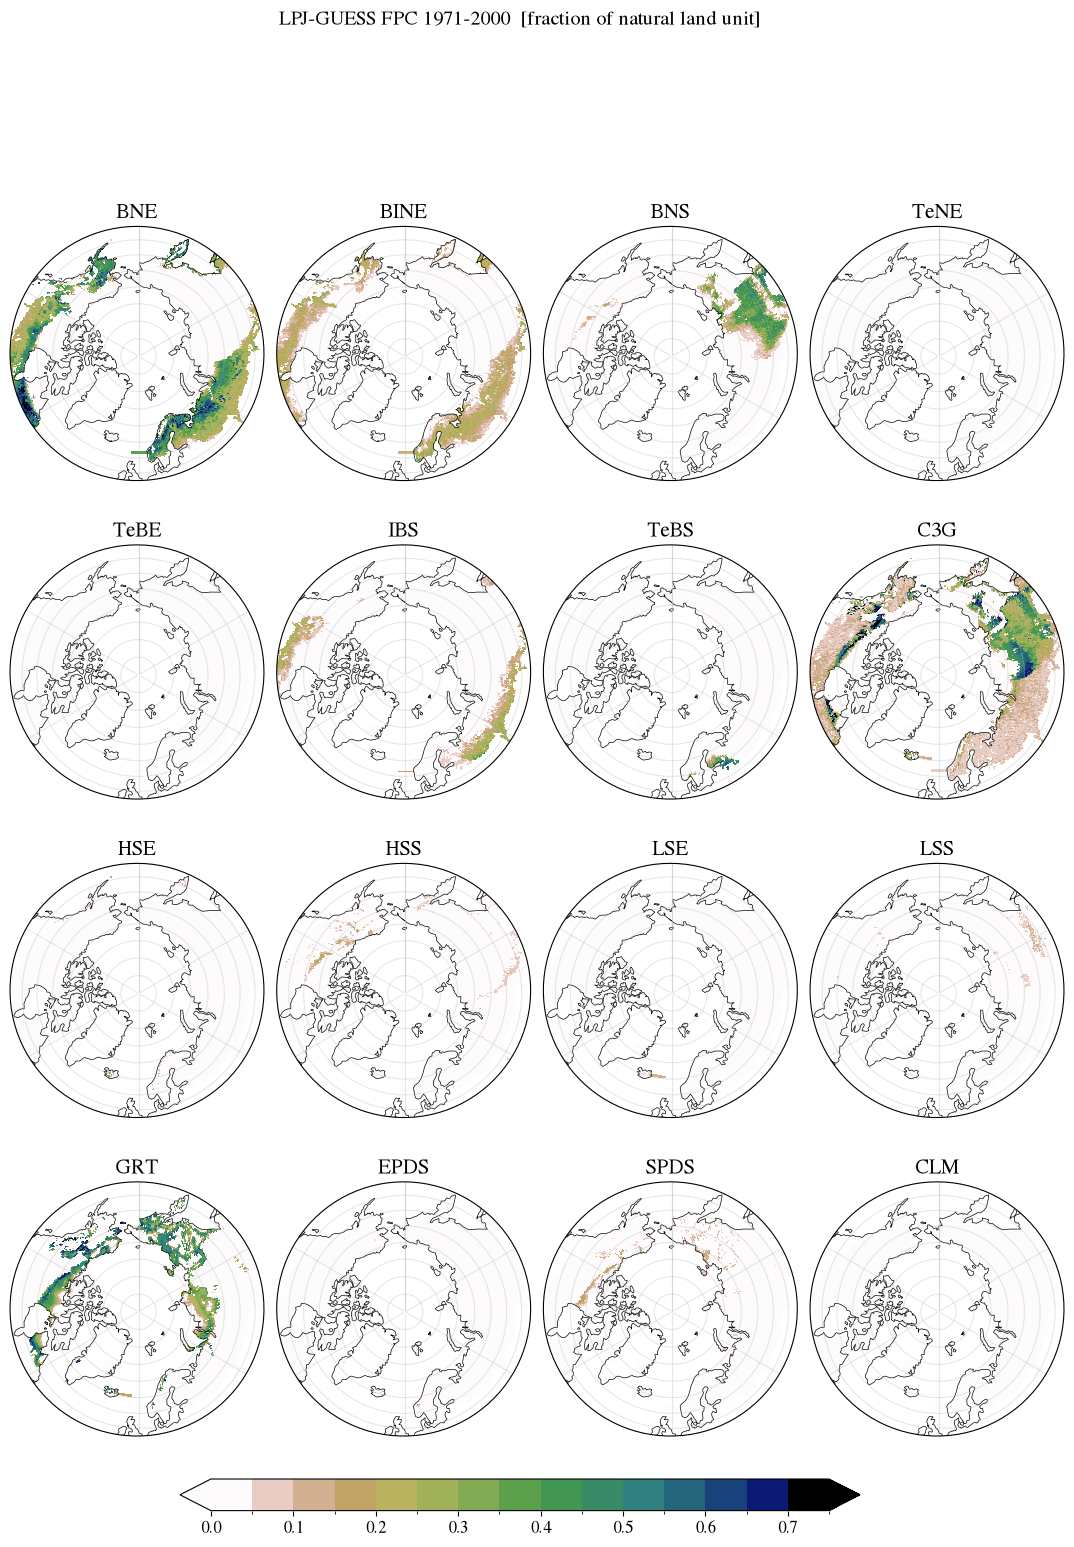

In [121]:
fig = panel([fpc_hist.sel(natpft=p) for p in LPJ_NATURAL], LPJ_NATURAL,
            ncols=4, vmin=0, vmax=0.7, cmap="gist_earth_r", levels=np.arange(0, 0.8, 0.05))
fig.suptitle("LPJ-GUESS FPC 1971-2000  [fraction of natural land unit]", y=1.01)

### B3 · LPJ-GUESS change (future - historical, native)
This is the raw signal we will impose. Compare to thesis Fig 5.11.

Text(0.5, 1.005, 'LPJ-GUESS FPC change (SSP585 2071-2100  -  1971-2000)')

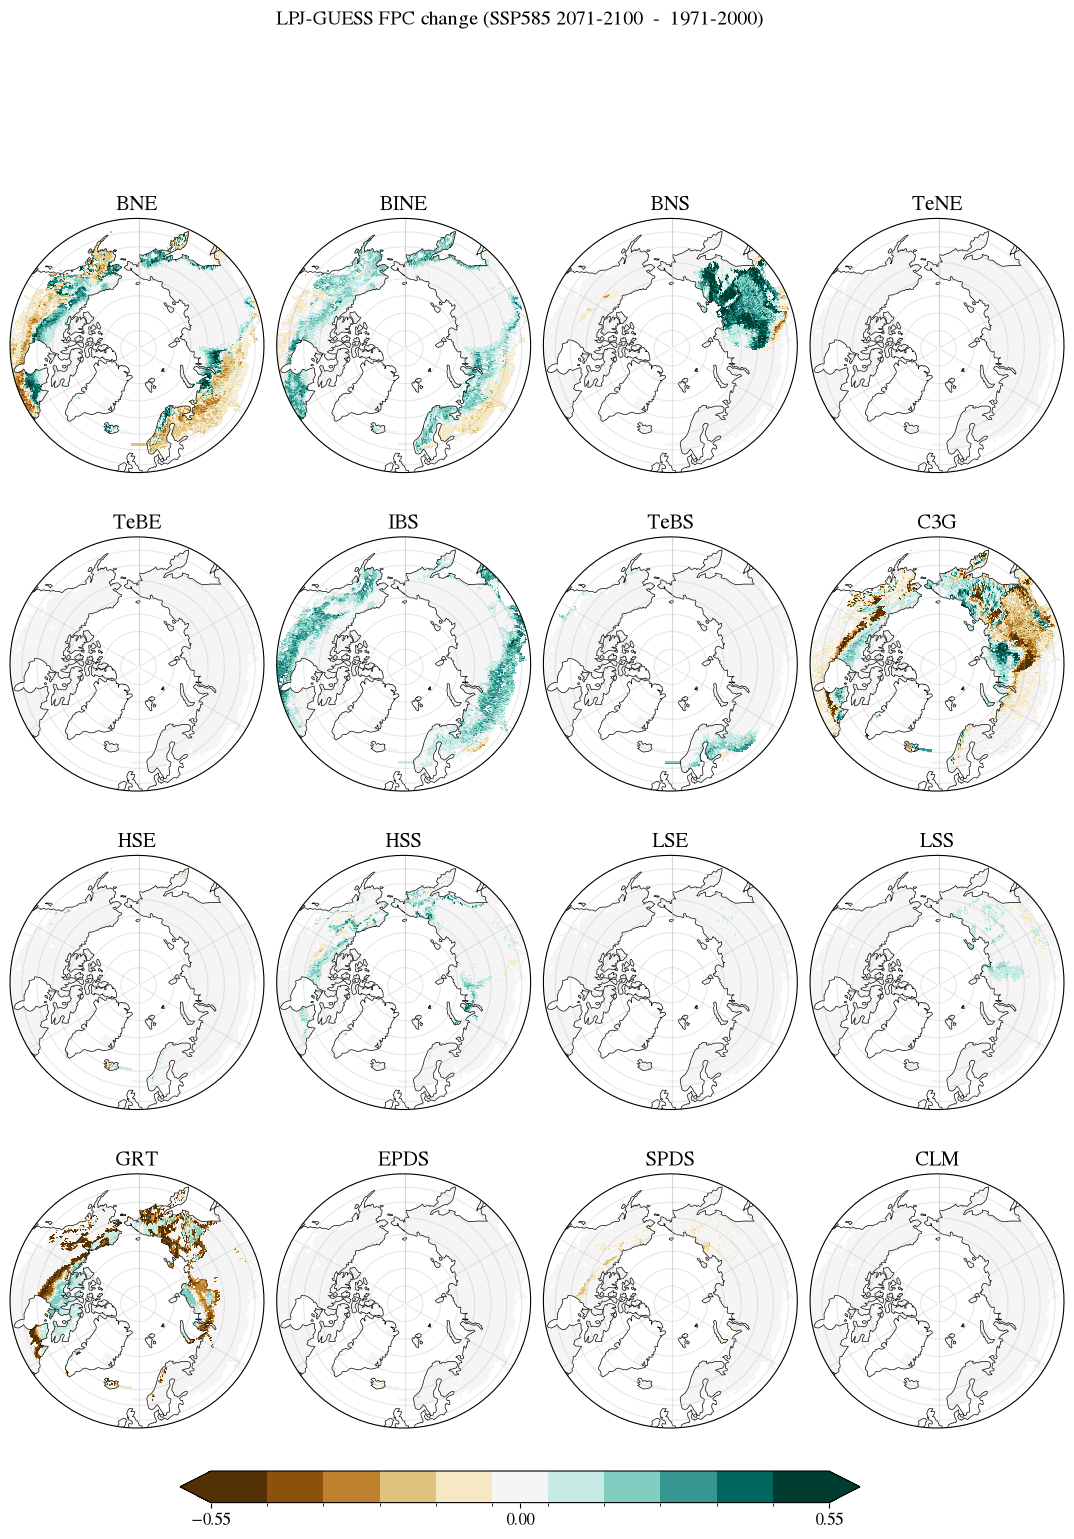

In [155]:
dfpc = fpc_fut - fpc_hist
fig = panel([dfpc.sel(natpft=p) for p in LPJ_NATURAL], LPJ_NATURAL,
            ncols=4, vmin=-0.5, vmax=0.5, diverging=True, cmap="BrBG", 
            levels=np.linspace(-0.55, 0.55, 12), cbar_nticks=3)
fig.suptitle("LPJ-GUESS FPC change (SSP585 2071-2100  -  1971-2000)", y=1.005)

### B4 · Aggregated LPJ vs aggregated CLM (vegetated total, minus bare)
Sum of the converted PFTs on the CLM grid vs CLM's own vegetated fraction.
Expect LPJ lower than CLM (FPC saturates / peatland excluded) — this is the systematic offset the anomaly method cancels.
LPJ's total veg is typically lower than CLM's (FPC saturates; peatland excluded). The anomaly method cancels this systematic offset — this panel is just to *see* it.

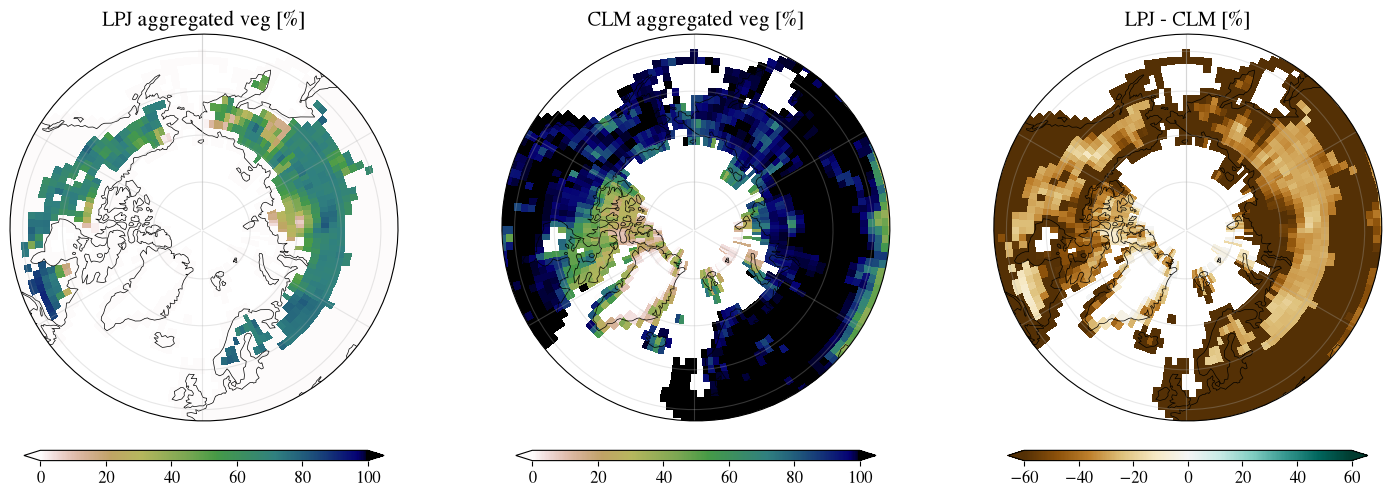

In [74]:
lpj_veg = (V_hist.sum("natpft") * 100).where(valid)          # % of land unit
clm_veg = (100 - pct_clm.sel(natpft=BARE)).where(valid)      # 100 - bare
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5),
                         subplot_kw={"projection": ccrs.Orthographic(0, 90)})
boreal_map(lpj_veg, "LPJ aggregated veg [%]", axes[0], vmin=0, vmax=100, cmap="gist_earth_r")
boreal_map(clm_veg, "CLM aggregated veg [%]", axes[1], vmin=0, vmax=100, cmap="gist_earth_r")
boreal_map(lpj_veg - clm_veg, "LPJ - CLM [%]", axes[2],
           vmin=-60, vmax=60, diverging=True, cmap="BrBG")
plt.tight_layout()

# PART C — Build the modified PCT_NAT_PFT
### C1 · Close the LPJ partition and take the zero-sum anomaly
We append bare = 1 - sum(PFTs) so each slice is a partition summing to 1 on the land-unit basis. The difference of two such partitions **sums to zero per cell** — that property is what lets us add it to CLM without renormalising everything (see C2). The assert guarantees it.

In [39]:
def close_partition(V):
    # bare fraction within the natural land unit = 1 - total vegetated fraction
    bare = (1.0 - V.sum("natpft")).clip(0, 1).assign_coords(natpft=BARE).expand_dims("natpft")
    closed = xr.concat([bare, V], dim="natpft").sortby("natpft")
    s = closed.sum("natpft")
    return closed / s.where(s > 0)          # tidy tiny (~1e-6) regrid residue
 
anomaly = close_partition(V_fut) - close_partition(V_hist)     # includes bare
_z = float(np.nanmax(np.abs(anomaly.sum("natpft"))))
assert _z < 1e-6, f"anomaly not closed ({_z:.1e})"            # must be ~0

### C2 · Apply the anomaly — BARE absorbs the net (no global renormalisation)
**This is the step that was buggy and is now fixed.** The change is added only to the target PFTs; bare (natpft 0) takes the opposite of their net so the column still sums to 100. We do **not** divide all PFTs by the column sum — doing so leaked up to 8 pp into untouched (temperate/tropical) PFTs whenever bare clipped. Here untouched PFTs are copied from the original and never touched, so they stay bit-identical by construction.

The `scale` term handles the ~41 "over-subscribed" cells where the target PFTs alone want >100%: there we shrink the positive increments proportionally (preserving the *relative* composition of the change) so they fit; elsewhere `scale == 1` and nothing changes.

In [46]:
# %% C2 — apply anomaly; untouched PFTs fixed; changed+bare share the rest
vchg = (anomaly * 100).fillna(0.0).sel(natpft=PFTS_TO_CHANGE)      # pp

untouched = [p for p in pct_clm.natpft.values
             if p not in PFTS_TO_CHANGE and p != BARE]
untouched_sum = pct_clm.sel(natpft=untouched).sum("natpft")        # fixed, stays put

# the changed PFTs + bare may occupy only what's left after untouched PFTs:
block_total = (100 - untouched_sum)                                # = orig(changed)+orig(bare)

# proposed new changed values (floor only); scale down if they exceed the block
proposed = (pct_clm.sel(natpft=PFTS_TO_CHANGE) + vchg).clip(0, None)   # floor at 0, no ceiling
prop_sum = proposed.sum("natpft")
over  = prop_sum > block_total
scale = xr.where(over, block_total / prop_sum.where(prop_sum > 0, 1), 1.0)
new_changed = proposed * scale                                     # no re-clip

pct_new = pct_clm.copy()
pct_new.loc[dict(natpft=PFTS_TO_CHANGE)] = new_changed
pct_new.loc[dict(natpft=BARE)] = block_total - new_changed.sum("natpft")  # exact, >=0
pct_new = xr.where(valid, pct_new, pct_clm)

n_scaled = int(over.where(valid).sum(skipna=True))
print(f"cells scaled for over-subscription: {n_scaled}")

cells scaled for over-subscription: 807


### C3 · Validate (robust to masking/NaN)
Rule learned the hard way: **reduce first, then mask.** `x.where(mask).sum()` turns masked cells into 0 (an all-NaN sum is 0), which then reads as "sum = 0 != 100". So we sum with `skipna=False`, *then* select valid cells, *then* drop non-finite before comparing.

In [47]:
# invariant 1: sums to 100 on valid cells
colsum = pct_new.sum("natpft", skipna=False)
resid = np.abs(colsum - 100).where(valid).values
resid = resid[np.isfinite(resid)]
assert resid.size > 0, "no valid cells — check the mask"
assert resid.max() < 1e-3, f"sum != 100 (worst {resid.max():.2e})"
 
# invariant 2: all values in [0,100] on valid cells
v = pct_new.where(valid)
assert float(v.min(skipna=True)) >= -1e-6 and float(v.max(skipna=True)) <= 100 + 1e-6
 
# invariant 3: untouched PFTs are bit-identical to the original
untouched = [p for p in pct_clm.natpft.values if p not in PFTS_TO_CHANGE and p != BARE]
du = np.abs((pct_new - pct_clm).sel(natpft=untouched).where(valid)).values
assert np.nanmax(du) < 1e-6, "an untouched PFT changed"
 
print(f"validation OK — {resid.size} valid cells, worst |sum-100| = {resid.max():.2e}")

validation OK — 4914 valid cells, worst |sum-100| = 4.26e-14


### C4 · Check the applied change (should match B3 x100 where converted)

Text(0.5, 1.02, 'Applied change to PCT_NAT_PFT  [percentage points]')

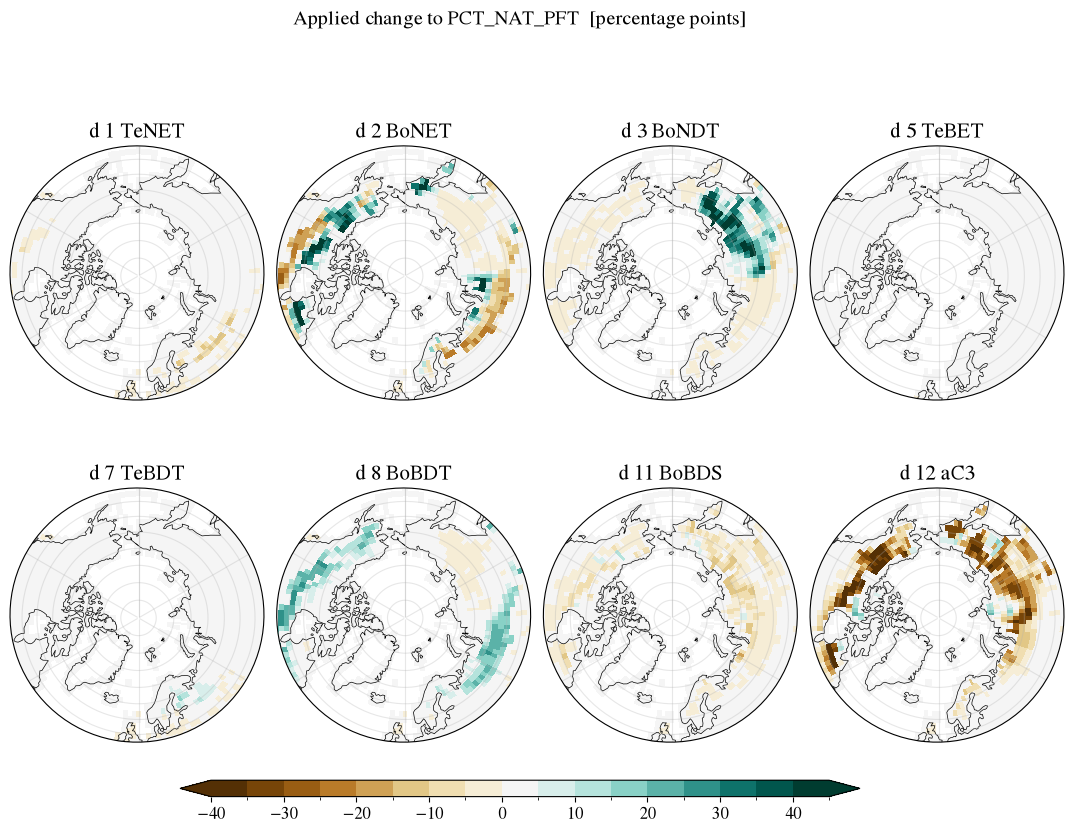

In [161]:
fig = panel([(pct_new - pct_clm).sel(natpft=p).where(valid) for p in PFTS_TO_CHANGE],
            [f"d {p} {CLM_NAMES.get(p,'')}" for p in PFTS_TO_CHANGE],
            vmin=-50, vmax=50, diverging=True, cmap="BrBG", levels=np.arange(-40, 45.1, 5))
fig.suptitle("Applied change to PCT_NAT_PFT  [percentage points]", y=1.02)

### C5 · Write back to CLM coordinates, add provenance, save
Convert lon back to 0..360 and to the `lsmlat/lsmlon` index dims, assign into a copy of the original dataset, then attach CF-style provenance attributes.`history` is *appended* to the base file's history so the chain is preserved.

In [66]:
ep = convert180_360(pct_new).fillna(0.0)
ep = ep.rename({"lat": "lsmlat", "lon": "lsmlon"}).drop_vars(["lsmlat", "lsmlon"])
surf_out = surf.copy(deep=True)
surf_out["PCT_NAT_PFT"].loc[dict(lsmlat=ep.lsmlat, lsmlon=ep.lsmlon, natpft=ep.natpft)] = ep
 
# quick written-field check (should be 0..100, no NaN)
_chk = surf_out["PCT_NAT_PFT"].sum("natpft")
print("written sum min/max:", float(_chk.min()), float(_chk.max()))
 
# provenance
surf_out.attrs["title"] = ("CLM surfdata with semi-realistic boreal vegetation "
                           "change from LPJ-GUESS (SSP5-8.5, 2100)")
surf_out.attrs["source_vegetation"] = "LPJ-GUESS FPC, GFDL-ESM4 forcing, SSP5-8.5"
surf_out.attrs["references"] = "Tang et al. (2023), <journal, doi>"   # <-- full cite
surf_out.attrs["contact"] = "Adele Zaini"                             # <-- edit
surf_out.attrs["history"] = (
    f"{_dt.date.today():%Y-%m-%d}: PCT_NAT_PFT modified from {SURF_IN.name} by "
    f"applying the LPJ-GUESS SSP5-8.5 (2071-2100) minus historical (1971-2000) "
    f"FPC anomaly, aggregated to CLM PFTs, closed on the natural land unit.\n"
    + surf.attrs.get("history", ""))
surf_out.attrs["comment"] = ("Only PCT_NAT_PFT edited; other land-unit fractions "
                             "unchanged. LAI left prognostic in CLM-BGC.")
 
surf_out.to_netcdf(SURF_OUT); print("saved:", SURF_OUT)

written sum min/max: 99.9999999999999 100.00000000000009
saved: /nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc


### C6 · Final result figure — change on CLM PFTs (paper figure)
Modified minus original, per modified PFT plus bare (the closure sink). Bare should mirror the vegetated gains. Prints the area-weighted mean change per PFT as a quick numeric summary (sum over shown PFTs ~ 0 = conservation).

area-weighted mean change [pp]:
  natpft  0 BG    : -0.147
  natpft  1 TeNET : -0.032
  natpft  2 BoNET : +0.133
  natpft  3 BoNDT : +0.461
  natpft  5 TeBET : -0.000
  natpft  7 TeBDT : +0.030
  natpft  8 BoBDT : +0.551
  natpft 11 BoBDS : -0.149
  natpft 12 aC3   : -0.847


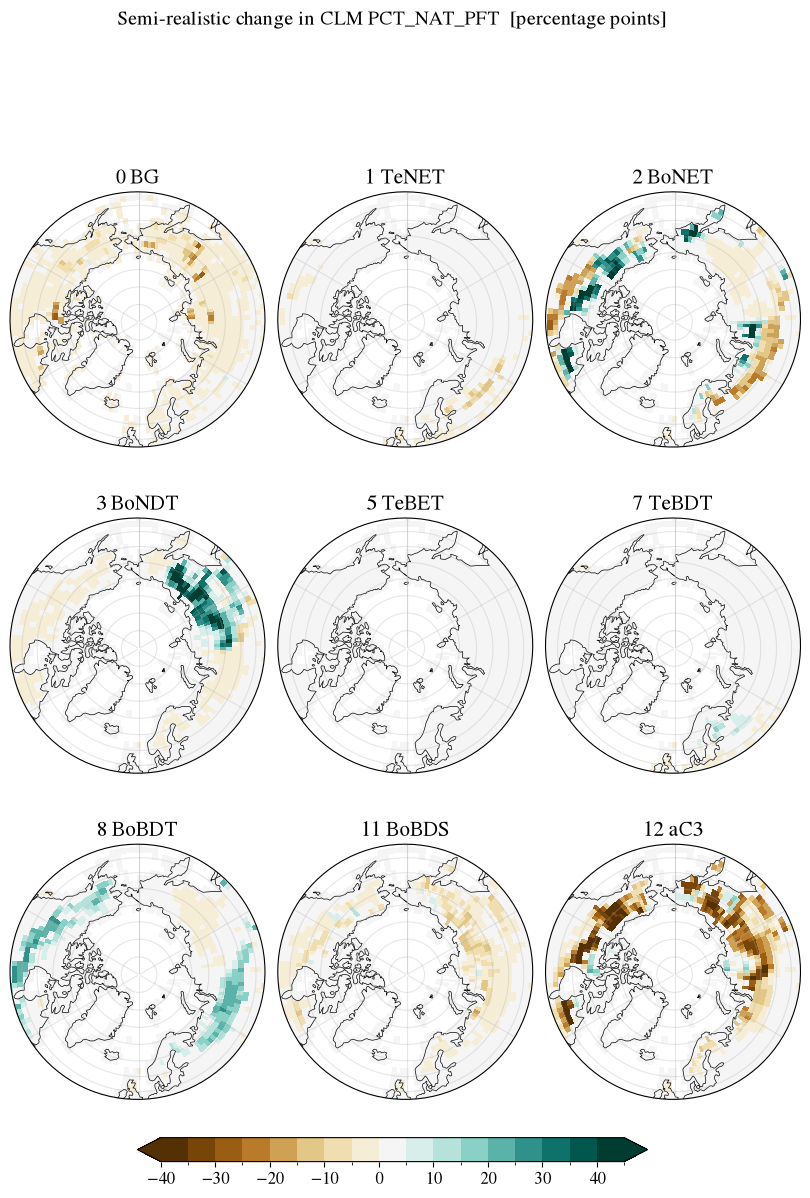

In [130]:
delta = (pct_new - pct_clm).where(valid)
show = [BARE] + PFTS_TO_CHANGE
fig = panel([delta.sel(natpft=p) for p in show],
            [f"{p} {CLM_NAMES.get(p,'')}" for p in show],
            ncols=3, vmin=-40, vmax=40, diverging=True, cmap="BrBG", levels=np.arange(-40, 46, 5))
fig.suptitle("Semi-realistic change in CLM PCT_NAT_PFT  [percentage points]", y=1.02)
#sm = plt.cm.ScalarMappable(cmap="BrBG", norm=MidpointNorm(-40, 40, 0.0))
#fig.colorbar(sm, ax=fig.axes, location="bottom", shrink=0.4, aspect=35,
             #pad=0.04, extend="both").set_label("change [% of natural veg land unit]")
 
w = np.cos(np.deg2rad(delta.lat))                       # area weight ~ cos(lat)
print("area-weighted mean change [pp]:")
for p in show:
    m = float((delta.sel(natpft=p) * w).sum() / (w * valid).sum())
    print(f"  natpft {p:>2} {CLM_NAMES.get(p,''):6s}: {m:+.3f}")

# PART D — Diagnostics (paper numbers)
### D1 · Colonization share per boreal tree PFT
How much of each tree's FPC gain comes from *new* cells (range shift) vs already-occupied cells (mostly densification). Backs the "~85-95%" statement.

In [68]:
EPS = 0.02
for j, cols in {2: ["BNE","BINE"], 3: ["BNS"], 8: ["IBS"]}.items():
    fh = fpc_hist_clm.sel(natpft=cols).sum("natpft")
    ff = fpc_fut_clm.sel(natpft=cols).sum("natpft")
    dF = (ff - fh).where(valid); pos = dF > 0
    colon = (fh < EPS) & (ff >= EPS)                    # absent hist -> present future
    tot = float(dF.where(pos).sum())
    pc = float(dF.where(pos & colon).sum())/tot*100 if tot > 0 else float("nan")
    print(f"CLM {j} {CLM_NAMES.get(j,''):6s}: +dFPC {tot:6.1f}   colonization {pc:4.0f}%")

CLM 2 BoNET : +dFPC   44.0   colonization   41%
CLM 3 BoNDT : +dFPC   60.4   colonization    9%
CLM 8 BoBDT : +dFPC   42.8   colonization   47%
